In [2]:
import pandas as pd 
df=pd.read_csv('ad_spend.csv')
df.sample(5)

,Ad Spend ($),Season,Revenue ($)
178,719,Winter,1084
85,557,Summer,752
174,325,Monsoon,375
54,602,Summer,660
90,538,Winter,705


In [3]:
df.shape

(200, 3)

In [4]:
df.isna().sum()

Ad Spend ($)    0
Season          0
Revenue ($)     0
dtype: int64

In [20]:
g=df.groupby('Season')[['Ad Spend ($)','Revenue ($)']].mean()

In [18]:
df.groupby('Revenue ($)')[['Ad Spend ($)']].mean()

,Ad Spend ($)
Revenue ($),
-79,224.0
-43,116.0
7,163.0
10,184.0
14,208.0
...,...
1456,915.0
1467,923.0
1475,877.0


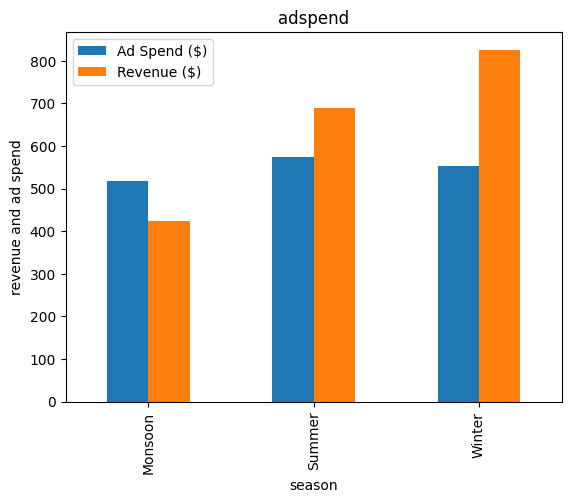

In [28]:
from matplotlib import pyplot as plt

ax=g.plot(kind="bar")
plt.xlabel('season')
plt.ylabel('revenue and ad spend')
plt.title('adspend')
plt.show()

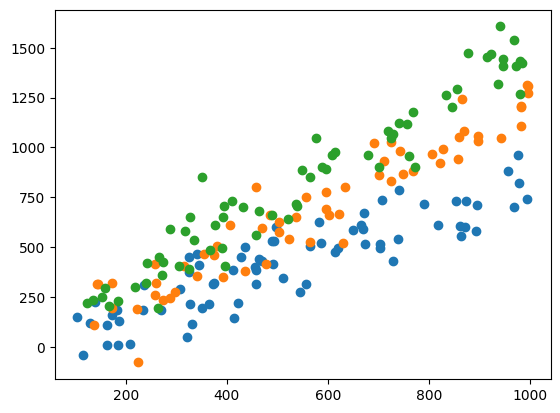

In [39]:
for season ,subdf in df.groupby('Season'):
    plt.scatter(subdf['Ad Spend ($)'],subdf['Revenue ($)'])

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report



In [43]:
df_encoded=pd.get_dummies(df,'Season',drop_first=True)
df_encoded


,Ad Spend ($),Revenue ($),Season_Summer,Season_Winter
0,463,440,False,False
1,158,297,False,True
2,328,214,False,False
3,322,48,False,False
4,726,1048,False,True
...,...,...,...,...
195,407,609,True,False
196,182,183,False,False
197,184,10,False,False
198,380,504,True,False


In [60]:
X=df_encoded[['Ad Spend ($)','Season_Summer','Season_Winter']]
y=df_encoded['Revenue ($)']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=10)

In [62]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)
model.score(X_test,y_test)

0.8882097000477289

In [63]:
from sklearn.tree import DecisionTreeRegressor
model=DecisionTreeRegressor()
model.fit(X_train,y_train)
model.score(X_test,y_test)

0.8972778553142061

In [61]:
from sklearn.ensemble import GradientBoostingRegressor
model=GradientBoostingRegressor()
model.fit(X_train,y_train)
model.score(X_test,y_test)

0.9149899654766234

In [65]:

y_pred=model.predict(X_test)

pd.DataFrame({
    'actual':y_pred,
    'predicted':y_test
})

,actual,predicted
59,558.0,605
5,1068.0,1125
20,733.0,699
198,348.0,504
52,1156.5,1310
19,161.0,320
162,1052.0,944
55,711.0,581
69,1410.0,1446
2,113.0,214
